# Project: Alzheimer's Disease Classification from Brain MRI Images Using Deep Learning

**Research Questions**

- Can a CNN classify Alzheimer's disease from 2D brain MRI slices?

- Does transfer learning overcome the limitations of training from scratch on a small medical imaging dataset?

## **1. Download, inspect and clean dataset and cross-sectional.csv**

In [ ]:
# ============================================================
# Imports
# ============================================================

import kagglehub
import pandas as pd
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib
import os
import shutil
import nibabel as nib
from PIL import Image
from pathlib import Path

from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from google.colab import drive

sns.set_style('darkgrid')

In [ ]:
# ============================================================
# Mount Drive
# ============================================================

drive.mount('/content/drive') #mount Google Drive to read images and csvs from there

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# Reproducibility
# ============================================================

# removes most run-to-run variation
seed = 42
tf.keras.utils.set_random_seed(seed)

In [ ]:
# ============================================================
# Downloading OASIS 1 dataset from Kaggle
# ============================================================

path = kagglehub.dataset_download("pbhanutejaswini/oasis-1-preprocessed-brain-mri")
print(path)

Using Colab cache for faster access to the 'oasis-1-preprocessed-brain-mri' dataset.
/kaggle/input/oasis-1-preprocessed-brain-mri


In [ ]:
# ============================================================
# Inspect oasis_cross-sectional CSV
# ============================================================

csv_path = '/content/drive/MyDrive/IT Academy/Especializacion/Proyecto/oasis_cross-sectional.csv'
df = pd.read_csv(csv_path)
print(df.shape)
df.head()

(436, 12)


,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
0,OAS1_0308_MR1,F,R,78,3.0,3.0,15.0,2.0,1401,0.703,1.253,NaN
1,OAS1_0351_MR1,M,R,86,1.0,4.0,15.0,2.0,1512,0.665,1.161,NaN
2,OAS1_0028_MR1,F,R,86,2.0,4.0,27.0,1.0,1449,0.738,1.211,NaN
3,OAS1_0031_MR1,M,R,88,1.0,4.0,26.0,1.0,1419,0.674,1.236,NaN
4,OAS1_0035_MR1,F,R,84,3.0,2.0,28.0,1.0,1402,0.695,1.252,NaN


In [ ]:
df['CDR'].value_counts()

,count
CDR,
0.0,135
0.5,70
1.0,28
2.0,2


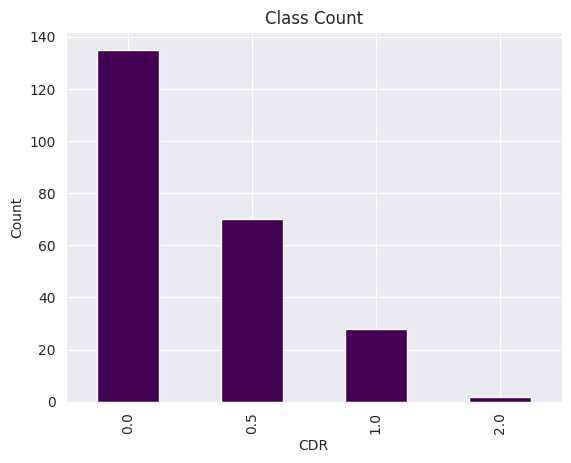

In [ ]:
df['CDR'].value_counts().plot(kind='bar', cmap = 'viridis')
plt.xlabel('CDR')
plt.ylabel('Count')
plt.title('Class Count')
plt.show()

In [ ]:
# ============================================================
# Add label based on CDR (2 Classes)
# ============================================================

df = pd.read_csv(csv_path)
df = df.dropna(subset=["CDR"])  # keep only patients with a CDR score

def cdr_to_label(cdr):
    if cdr == 0:
        return "non_demented"
    else:
        return "alzheimer"

df["label"] = df["CDR"].apply(cdr_to_label)

print(df.shape)
df.head()

(235, 13)


,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay,label
0,OAS1_0308_MR1,F,R,78,3.0,3.0,15.0,2.0,1401,0.703,1.253,NaN,alzheimer
1,OAS1_0351_MR1,M,R,86,1.0,4.0,15.0,2.0,1512,0.665,1.161,NaN,alzheimer
2,OAS1_0028_MR1,F,R,86,2.0,4.0,27.0,1.0,1449,0.738,1.211,NaN,alzheimer
3,OAS1_0031_MR1,M,R,88,1.0,4.0,26.0,1.0,1419,0.674,1.236,NaN,alzheimer
4,OAS1_0035_MR1,F,R,84,3.0,2.0,28.0,1.0,1402,0.695,1.252,NaN,alzheimer


In [ ]:
df_slices = df["label"].value_counts()
df_slices.head()

,count
label,
non_demented,135
alzheimer,100


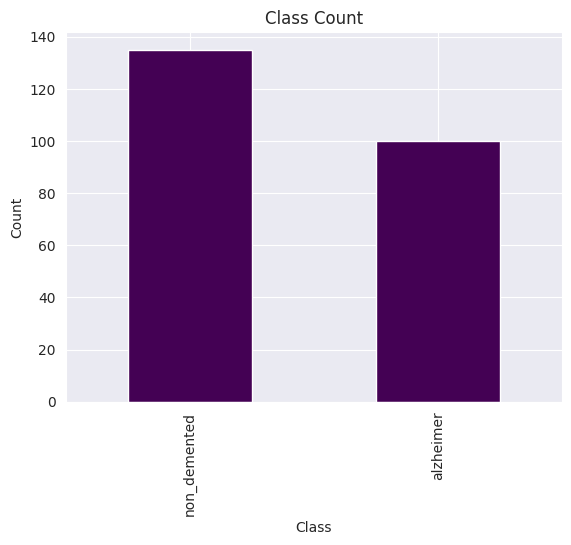

In [ ]:
df_slices.plot(kind='bar', cmap = 'viridis')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Count')
plt.show()

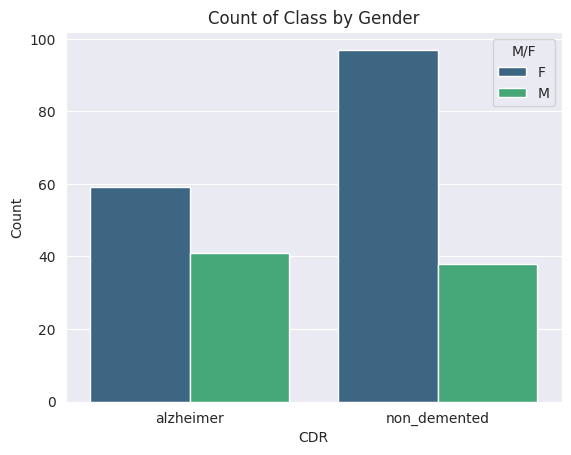

In [ ]:
sns.countplot(data=df, x='label', hue='M/F', palette='viridis')
plt.xlabel('CDR')
plt.ylabel('Count')
plt.title('Count of Class by Gender')
plt.show()

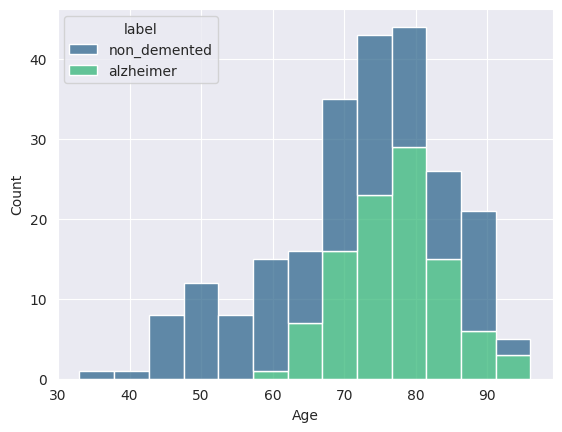

In [ ]:
sns.histplot(
    data=df,
    x='Age',
    hue='label',
    hue_order=['non_demented', 'alzheimer'],
    multiple='stack',
    palette='viridis'
);

In [ ]:
df.loc[df['label'] == 'alzheimer'].describe().round(2)

,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
count,100.00,100.00,83.00,100.00,100.00,100.00,100.00,100.00,0.0
mean,76.76,2.82,2.75,24.32,0.67,1483.75,0.72,1.20,NaN
std,7.12,1.30,1.17,4.17,0.29,168.32,0.04,0.13,NaN
min,62.00,1.00,1.00,14.00,0.50,1171.00,0.64,0.88,NaN
25%,72.00,2.00,2.00,21.75,0.50,1358.00,0.69,1.12,NaN
50%,77.00,2.50,3.00,26.00,0.50,1464.00,0.72,1.20,NaN
75%,81.00,4.00,4.00,28.00,1.00,1565.25,0.75,1.29,NaN
max,96.00,5.00,5.00,30.00,2.00,1992.00,0.80,1.50,NaN


In [ ]:
df = df.loc[df['Age'] >= 60]
print(df.shape)
df.head()

(198, 13)


,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay,label
0,OAS1_0308_MR1,F,R,78,3.0,3.0,15.0,2.0,1401,0.703,1.253,NaN,alzheimer
1,OAS1_0351_MR1,M,R,86,1.0,4.0,15.0,2.0,1512,0.665,1.161,NaN,alzheimer
2,OAS1_0028_MR1,F,R,86,2.0,4.0,27.0,1.0,1449,0.738,1.211,NaN,alzheimer
3,OAS1_0031_MR1,M,R,88,1.0,4.0,26.0,1.0,1419,0.674,1.236,NaN,alzheimer
4,OAS1_0035_MR1,F,R,84,3.0,2.0,28.0,1.0,1402,0.695,1.252,NaN,alzheimer


In [ ]:
df_slices = df["label"].value_counts()
df_slices.head()

,count
label,
alzheimer,100
non_demented,98


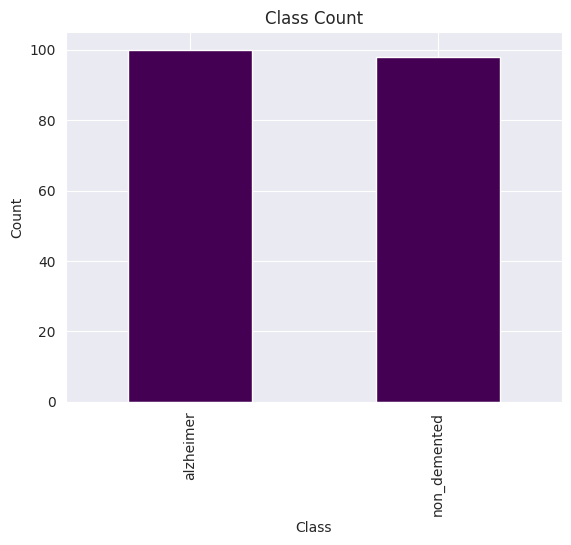

In [ ]:
df_slices.plot(kind='bar', cmap = 'viridis')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Count')
plt.show()

## **2. Slice 3D MRI scans (10 slices per patient)**

In [ ]:
# ============================================================
# Adding nii filename to dataframe
# ============================================================

#Adding nii_filename in the dataframe

nii_dir = f'{path}/OASIS_Clean_Data/OASIS_Clean_Data'

nii_files = os.listdir(nii_dir) #list all .nii filenames

#Create a dictionary mapping subject IDs to filenames
nii_lookup = {}

for file_name in nii_files:
    subject_id = file_name.split("_mpr")[0]
    nii_lookup[subject_id] = file_name

df["nii_filename"] = df["ID"].map(nii_lookup)

df = df.dropna(subset=["nii_filename"]) #remove patients without MRI files

print(df.shape)
df.head()

(198, 14)


,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay,label,nii_filename
0,OAS1_0308_MR1,F,R,78,3.0,3.0,15.0,2.0,1401,0.703,1.253,NaN,alzheimer,OAS1_0308_MR1_mpr_n4_anon_111_t88_masked_gfc.nii
1,OAS1_0351_MR1,M,R,86,1.0,4.0,15.0,2.0,1512,0.665,1.161,NaN,alzheimer,OAS1_0351_MR1_mpr_n4_anon_111_t88_masked_gfc.nii
2,OAS1_0028_MR1,F,R,86,2.0,4.0,27.0,1.0,1449,0.738,1.211,NaN,alzheimer,OAS1_0028_MR1_mpr_n4_anon_111_t88_masked_gfc.nii
3,OAS1_0031_MR1,M,R,88,1.0,4.0,26.0,1.0,1419,0.674,1.236,NaN,alzheimer,OAS1_0031_MR1_mpr_n4_anon_111_t88_masked_gfc.nii
4,OAS1_0035_MR1,F,R,84,3.0,2.0,28.0,1.0,1402,0.695,1.252,NaN,alzheimer,OAS1_0035_MR1_mpr_n4_anon_111_t88_masked_gfc.nii


In [ ]:
# ============================================================
# Creating function to slice .nii files
# ============================================================

out_dir = Path("output/slices_2_classes")

slice_range = (80, 120)
num_slices = 10
brain_view = 2  # 0=sagittal, 1=coronal, 2=axial/transverse

def extract_slices(
    img_path,
    out_dir,
    subject_id,
    slice_range=slice_range,
    n_slices=num_slices,
    axis=brain_view,
):
    img = nib.load(img_path) #loading .nii MRI file
    data = img.get_fdata() #converting MRI into numpy array (3D matrix)

    #convert 4D scans to 3D if necessary
    if data.ndim == 4:
        data = data[..., 0]

    #getting 10 slices from the range provided evenly-spaced out
    start, end = slice_range
    slice_indices = np.linspace(start, end, n_slices, dtype=int)

    out_dir.mkdir(parents=True, exist_ok=True)

    saved_paths = []

    for idx in slice_indices:
        sl = data[:, :, idx]

        sl = np.rot90(sl) #rotate slice 90 degrees

        #normalize intensities to 0-255
        sl = sl - sl.min()
        sl = sl / (sl.max() + 1e-8)
        sl = (sl * 255).astype(np.uint8)

        out_path = out_dir / f"{subject_id}_slice{idx}.png"

        Image.fromarray(sl).save(out_path) #converting from numpy array to PIL image and saving it to PNG

        saved_paths.append(str(out_path))

    return saved_paths #returning list of saved images

In [ ]:
# ============================================================
# Slicing and saving images in a folder structure in output
# ============================================================

nii_dir = Path(nii_dir)

manifest_rows = []

for row in df.itertuples(index=False):

    subject_id = row.ID
    label = row.label

    nii_path = nii_dir / row.nii_filename
    class_out_dir = out_dir / label / subject_id

    try:
        saved_paths = extract_slices(
            img_path=nii_path,
            out_dir=class_out_dir,
            subject_id=subject_id,
        )

        manifest_rows.extend(
            {
                "subject_id": subject_id,
                "label": label,
                "cdr": row.CDR,
                "image_path": path,
            }
            for path in saved_paths
        )

    except Exception as e:
        print(f"Failed to process {subject_id}: {e}")

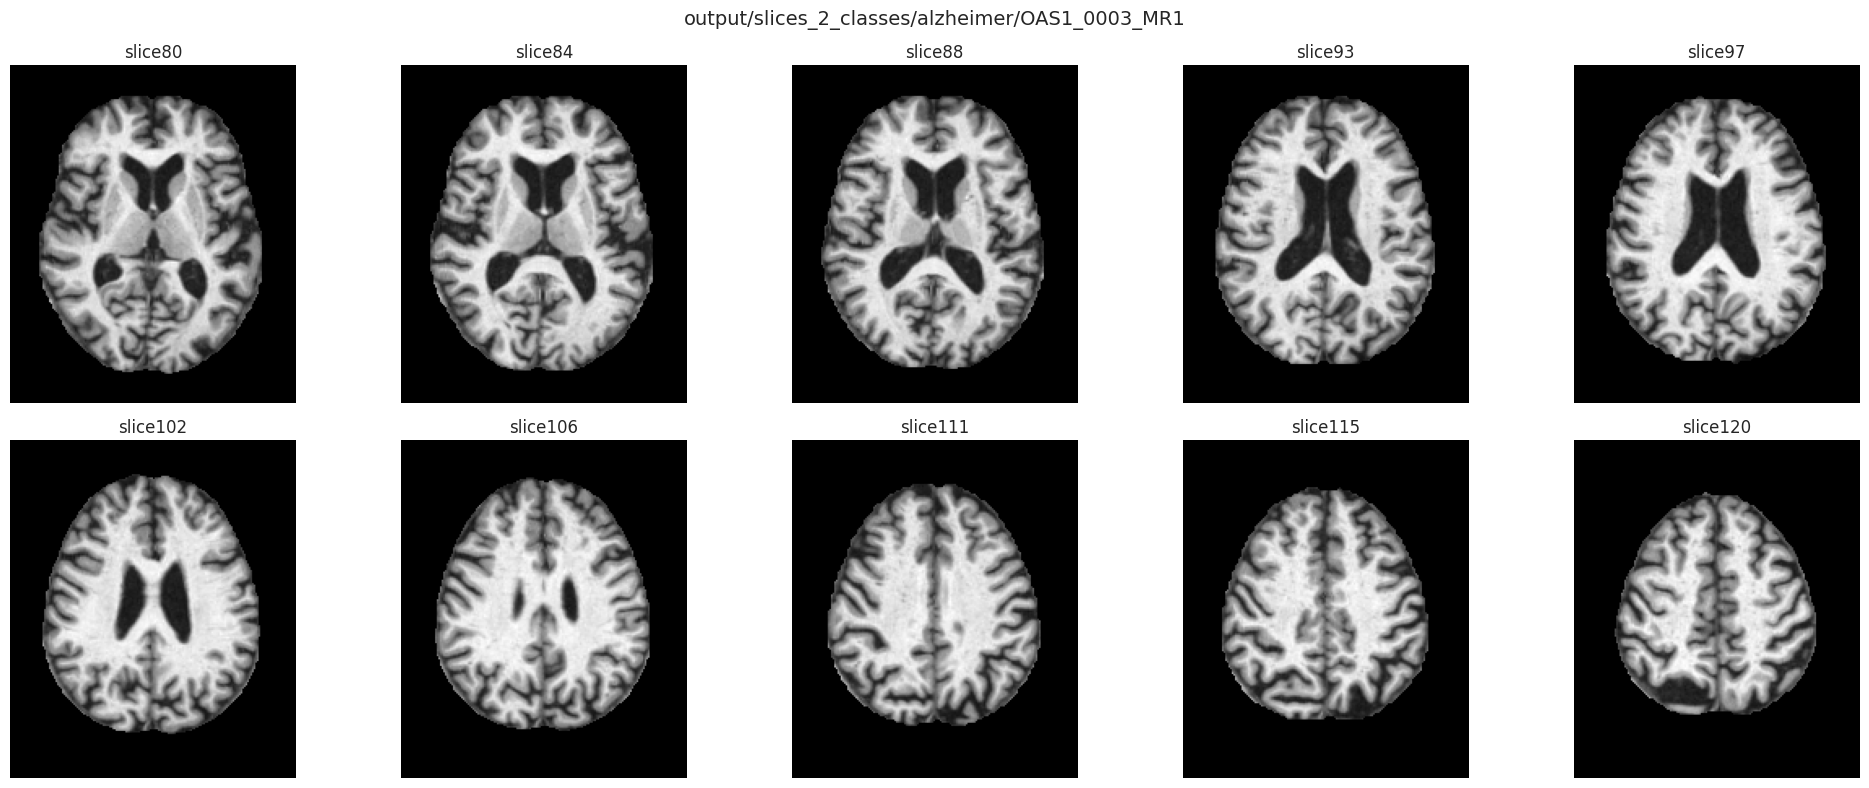

In [ ]:
# ============================================================
# Reviewing slices of Alzheimer class
# ============================================================

patient_dir = "output/slices_2_classes/alzheimer/OAS1_0003_MR1"

# get all slice files, sorted by slice number
slices = sorted(os.listdir(patient_dir),
                key=lambda x: int(x.split("slice")[1].split(".")[0]))

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, fname in zip(axes.flat, slices):
    img = Image.open(os.path.join(patient_dir, fname))
    ax.imshow(img, cmap="gray")
    ax.set_title(fname.split("_")[-1].replace(".png", ""))
    ax.axis("off")

plt.suptitle(patient_dir, fontsize=14)
plt.tight_layout()
plt.show()

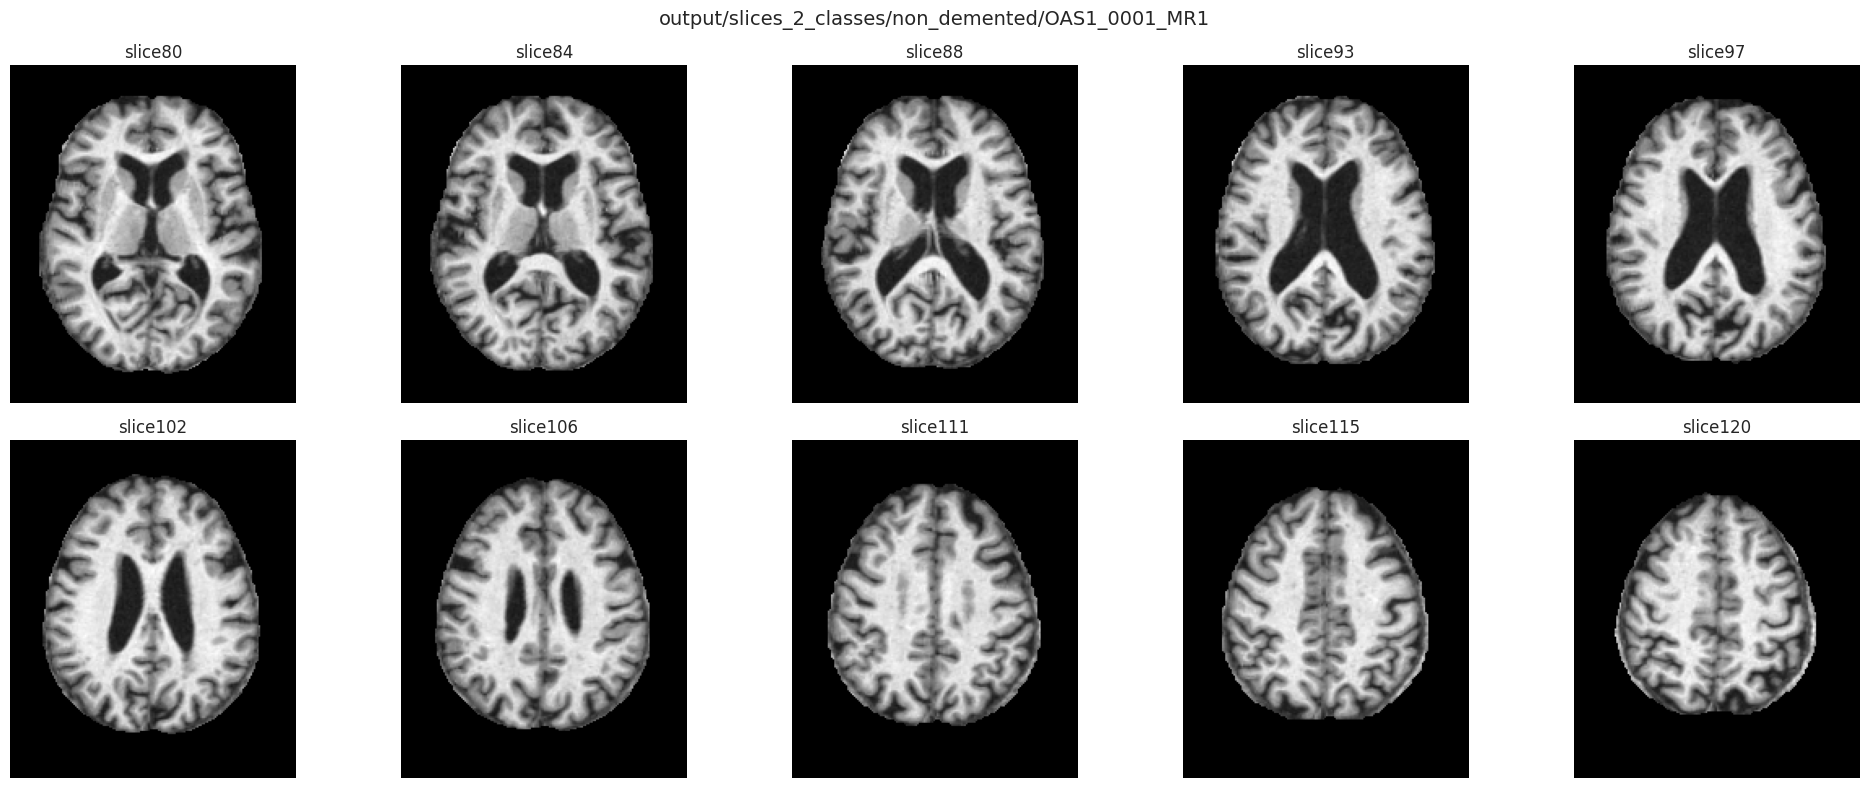

In [ ]:
# ============================================================
# Reviewing slices of Non_demented class
# ============================================================

patient_dir = "output/slices_2_classes/non_demented/OAS1_0001_MR1"

slices = sorted(os.listdir(patient_dir),
                key=lambda x: int(x.split("slice")[1].split(".")[0]))

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, fname in zip(axes.flat, slices):
    img = Image.open(os.path.join(patient_dir, fname))
    ax.imshow(img, cmap="gray")
    ax.set_title(fname.split("_")[-1].replace(".png", ""))
    ax.axis("off")

plt.suptitle(patient_dir, fontsize=14)
plt.tight_layout()
plt.show()

- **Slices 80-84** catch the lower brain where you'd see the temporal lobes and hippocampus. Notice the deep grooves (sulci) and how the grey matter folds seem widely spaced with dark gaps — that's cortical atrophy. In a healthy age-matched brain, the folds would be tighter with less visible cerebrospinal fluid between them.
- **Slices 88-106** The large dark butterfly shape in the centre are the lateral ventricles. Alzheimer's patient have them noticeably enlarged (a sign of brain tissue loss around them). The wider and more pronounced that dark region, the more atrophy has occurred.

In [ ]:
# ============================================================
# Creating manifest_df
# ============================================================

manifest_df = pd.DataFrame(manifest_rows)

# Adding numeric labels
label_map = {
    "non_demented": 0,
    "alzheimer": 1,
}

manifest_df["label_id"] = manifest_df["label"].map(label_map)

# Save it back, now with the split column included
manifest_df.to_csv("output/slices_2_classes/manifest.csv", index=False)

print(manifest_df.shape)
manifest_df.head()

(1980, 5)


,subject_id,label,cdr,image_path,label_id
0,OAS1_0308_MR1,alzheimer,2.0,output/slices_2_classes/alzheimer/OAS1_0308_MR...,1
1,OAS1_0308_MR1,alzheimer,2.0,output/slices_2_classes/alzheimer/OAS1_0308_MR...,1
2,OAS1_0308_MR1,alzheimer,2.0,output/slices_2_classes/alzheimer/OAS1_0308_MR...,1
3,OAS1_0308_MR1,alzheimer,2.0,output/slices_2_classes/alzheimer/OAS1_0308_MR...,1
4,OAS1_0308_MR1,alzheimer,2.0,output/slices_2_classes/alzheimer/OAS1_0308_MR...,1


In [ ]:
# ============================================================
# Copying slices and manifest in drive
# ============================================================

#Copy slices and split in drive to avoid having to rerun all this code everytime it gets colab gets disconnected
project_path = '/content/drive/MyDrive/AlzheimersProject'
os.makedirs(project_path, exist_ok=True)

shutil.copytree('output/slices_2_classes', os.path.join(project_path, 'slices_2_classes'), dirs_exist_ok=True)